# Домашнее задание 1. Знакомство с API
Студент: *ФИО*, группа, дата

Задание выполняется в рамках модуля 1 «Проектирование API». Вы закрепите навыки разработки API, используя подход API-first.

> Чтобы получить максимальный балл, убедитесь, что ваш ноутбук запускается с нуля, структура понятна, а в выводах вы объясняете свои решения.  

## Подготовка окружения

In [ ]:
!pip install requests -qqq
!pip install "fastapi[all]" "uvicorn[standard]" -qqq

### Задание 1. Создать CRUD на основе встроенного HTTP сервера Python

Задача: создать сервер, который будет содержать код API с двумя методами HTTP.

*Здесь мы **специально** берем сильно устаревшую версию веб-сервера, написанную во времена Python 2.0 в 2000 году. Обратите внимание на многословность кода веб-сервера.*


In [ ]:
import pandas as pd
import datetime
df = pd.DataFrame([['Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг',
  1025,
  329,
  11,
  'c',
  'антифриз',
  datetime.datetime(2026, 10, 16, 12, 36, 22)],
 ['Антифриз готовый фиолетовый Синтек MULTIFREEZE 5кг',
  250,
  315,
  38,
  'b',
  'антифриз',
  datetime.datetime(2025, 12, 11, 8, 25, 31)],
 ['Антифриз G11 зеленый',
  120,
  329,
  61,
  'b',
  'антифриз',
  datetime.datetime(2025, 6, 15, 15, 36, 30)],
 ['Антифриз Antifreeze OEM China OAT red -40 5кг',
  390,
  504,
  65,
  'c',
  'антифриз',
  datetime.datetime(2025, 11, 30, 4, 12, 39)],
 ['Антифриз G11 зеленый',
  135,
  407,
  93,
  'b',
  'антифриз',
  datetime.datetime(2026, 8, 25, 3, 24, 1)],
])

df.columns = ['Наименование товара', 'Цена, руб.', 'cpm', 'Скидка', 'tp', 'Категория', 'dt']
df['Год'] = df['dt'].dt.year
df=df.drop(['cpm',  'tp', 'dt'],axis=1)
display(df)


,Наименование товара,"Цена, руб.",Скидка,Категория,Год
0,"Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг",1025,11,антифриз,2026
1,Антифриз готовый фиолетовый Синтек MULTIFREEZE...,250,38,антифриз,2025
2,Антифриз G11 зеленый,120,61,антифриз,2025
3,Антифриз Antifreeze OEM China OAT red -40 5кг,390,65,антифриз,2025
4,Антифриз G11 зеленый,135,93,антифриз,2026


In [ ]:
import http.server
import socketserver
import json
import re
import threading
import socket

# --- In-memory database (список словарей из DataFrame) ---
items_db = df.to_dict(orient='records')
# Добавляем каждому товару уникальный id
for idx, item in enumerate(items_db):
    item['id'] = idx

class SimpleCRUDHandler(http.server.BaseHTTPRequestHandler):
    """Простой HTTP-обработчик с поддержкой GET-методов для товаров."""

    def _send_json_response(self, status_code, data=None):
        self.send_response(status_code)
        self.send_header('Content-Type', 'application/json; charset=utf-8')
        self.end_headers()
        if data is not None:
            self.wfile.write(json.dumps(data, ensure_ascii=False).encode('utf-8'))

    def _parse_json_body(self):
        content_length = int(self.headers.get('Content-Length', 0))
        body = self.rfile.read(content_length)
        try:
            return json.loads(body.decode('utf-8'))
        except json.JSONDecodeError:
            return None

    def do_GET(self):
        """
        GET /items      — получить весь список товаров
        GET /items/{id} — получить один товар по ID
        """
        match_all = re.match(r'^/items/?$', self.path)
        match_single = re.match(r'^/items/(\d+)/?$', self.path)

        if match_all:
            # Возвращаем полный список товаров
            self._send_json_response(200, items_db)
        elif match_single:
            item_id = int(match_single.group(1))
            # Ищем товар по id
            item = next((i for i in items_db if i['id'] == item_id), None)
            if item:
                self._send_json_response(200, item)
            else:
                self._send_json_response(404, {'detail': 'Item not found'})
        else:
            self._send_json_response(404, {'detail': 'Not Found'})

    def log_message(self, format, *args):
        """Подавляем лишний вывод в консоль."""
        pass


PORT = 8000

# Останавливаем предыдущий сервер, если он был запущен ранее
try:
    httpd.shutdown()
    httpd.server_close()
    print("Предыдущий сервер остановлен.")
except:
    pass

# Разрешаем повторное использование адреса
socketserver.TCPServer.allow_reuse_address = True
httpd = socketserver.TCPServer(("0.0.0.0", PORT), SimpleCRUDHandler)

def run_server():
    print(f"Legacy HTTP server running on port {PORT}...")
    httpd.serve_forever()

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()

print(f" Server started on http://127.0.0.1:{PORT}")
print("   GET /items     — список всех товаров")
print("   GET /items/{id} — товар по ID")

def stop_server():
    print("Stopping server...")
    httpd.shutdown()
    httpd.server_close()
    print("Server stopped.")

Legacy HTTP server running on port 8000... Server started on http://127.0.0.1:8000
   GET /items     — список всех товаров
   GET /items/{id} — товар по ID



In [ ]:
items_db

[{'Наименование товара': 'Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг',
  'Цена, руб.': 1025,
  'Скидка': 11,
  'Категория': 'антифриз',
  'Год': 2026,
  'id': 0},
 {'Наименование товара': 'Антифриз готовый фиолетовый Синтек MULTIFREEZE 5кг',
  'Цена, руб.': 250,
  'Скидка': 38,
  'Категория': 'антифриз',
  'Год': 2025,
  'id': 1},
 {'Наименование товара': 'Антифриз G11 зеленый',
  'Цена, руб.': 120,
  'Скидка': 61,
  'Категория': 'антифриз',
  'Год': 2025,
  'id': 2},
 {'Наименование товара': 'Антифриз Antifreeze OEM China OAT red -40 5кг',
  'Цена, руб.': 390,
  'Скидка': 65,
  'Категория': 'антифриз',
  'Год': 2025,
  'id': 3},
 {'Наименование товара': 'Антифриз G11 зеленый',
  'Цена, руб.': 135,
  'Скидка': 93,
  'Категория': 'антифриз',
  'Год': 2026,
  'id': 4}]

In [ ]:
!kill 78

In [ ]:
! curl https://2ip.ru

34.106.200.60


### Задание 2. Подключиться к этому серверу

Подумайте, какие глаголы HTTP нужно использовать для разных методов запроса

```python
import requests
try:
    url = "http://127.0.0.1:8000/items"
    response = requests.get(url)
    print(response.json()[0]['0'])
except Exception as e:
    print(f"Ошибка: {e}")
```

Сервер должен отвечать валидным JSON. Содержание JSONa не важно, главное, чтобы он был валидным.


In [ ]:
import requests, json, time

BASE = "http://127.0.0.1:8000"

# Ждём, пока сервер станет доступен (до 5 секунд)
for _ in range(10):
    try:
        requests.get(f"{BASE}/items", timeout=1)
        break
    except Exception:
        time.sleep(0.5)
else:
    print(" Сервер не отвечает! Убедитесь, что ячейка с сервером (выше) запущена.")

# --- Тест 1: GET /items — весь список товаров ---
print("=" * 50)
print("GET /items — список всех товаров")
print("=" * 50)
resp = requests.get(f"{BASE}/items")
print(f"Status: {resp.status_code}")
data = resp.json()
print(f"Кол-во товаров: {len(data)}")
for item in data:
    print(f"  id={item['id']}  {item['Наименование товара']}  —  {item['Цена, руб.']} руб.")

# --- Тест 2: GET /items/0 — один товар ---
print("\n" + "=" * 50)
print("GET /items/0 — товар с id=0")
print("=" * 50)
resp = requests.get(f"{BASE}/items/0")
print(f"Status: {resp.status_code}")
print(json.dumps(resp.json(), ensure_ascii=False, indent=2))

# --- Тест 3: GET /items/999 — несуществующий товар ---
print("\n" + "=" * 50)
print("GET /items/999 — несуществующий товар")
print("=" * 50)
resp = requests.get(f"{BASE}/items/999")
print(f"Status: {resp.status_code}")
print(resp.json())

GET /items — список всех товаров
Status: 200
Кол-во товаров: 5
  id=0  Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг  —  1025 руб.
  id=1  Антифриз готовый фиолетовый Синтек MULTIFREEZE 5кг  —  250 руб.
  id=2  Антифриз G11 зеленый  —  120 руб.
  id=3  Антифриз Antifreeze OEM China OAT red -40 5кг  —  390 руб.
  id=4  Антифриз G11 зеленый  —  135 руб.

GET /items/0 — товар с id=0
Status: 200
{
  "Наименование товара": "Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг",
  "Цена, руб.": 1025,
  "Скидка": 11,
  "Категория": "антифриз",
  "Год": 2026,
  "id": 0
}

GET /items/999 — несуществующий товар
Status: 404
{'detail': 'Item not found'}


### Задание 3. Описать структуру запросов и их ответы в формате OpenAPI

Используйте редактор [Swagger](https://editor.swagger.io/), чтобы проверить свою спецификацию. Ниже — валидный YAML с примерами ответов в форматах **JSON** и **XML**.

```yaml
openapi: 3.0.3
info:
  title: Антифриз API
  description: CRUD API для управления каталогом антифризов
  version: "1.0.0"

paths:
  /items:
    get:
      operationId: getItems
      summary: Получить список всех товаров
      responses:
        '200':
          description: Успешный ответ — массив товаров
          content:
            application/json:
              schema:
                type: array
                items:
                  $ref: '#/components/schemas/Item'
              example:
                - id: 0
                  name: "Антифриз EURO G11 (-45°C) зелёный, концентрат 5кг"
                  price: 1025
                  discount: 11
                  category: "Антифриз"
                  year: 2026
            application/xml:
              schema:
                type: array
                items:
                  $ref: '#/components/schemas/Item'
              example: |
                <?xml version="1.0" encoding="UTF-8"?>
                <items>
                  <item>
                    <id>0</id>
                    <name>Антифриз EURO G11 (-45°C) зелёный, концентрат 5кг</name>
                    <price>1025</price>
                    <discount>11</discount>
                    <category>Антифриз</category>
                    <year>2026</year>
                  </item>
                </items>

  /items/{item_id}:
    get:
      operationId: getItem
      summary: Получить товар по ID
      parameters:
        - name: item_id
          in: path
          required: true
          schema:
            type: integer
      responses:
        '200':
          description: Товар найден
          content:
            application/json:
              schema:
                $ref: '#/components/schemas/Item'
            application/xml:
              example: |
                <?xml version="1.0" encoding="UTF-8"?>
                <item>
                  <id>0</id>
                  <name>Антифриз EURO G11 (-45°C)</name>
                  <price>1025</price>
                </item>
        '404':
          description: Товар не найден
          content:
            application/json:
              example:
                detail: "Item not found"
    post:
      operationId: createItem
      summary: Добавить новый товар
      requestBody:
        required: true
        content:
          application/json:
            schema:
              $ref: '#/components/schemas/ItemCreate'
      responses:
        '201':
          description: Товар создан
          content:
            application/json:
              schema:
                $ref: '#/components/schemas/Item'
    put:
      operationId: updateItem
      summary: Обновить товар по ID
      parameters:
        - name: item_id
          in: path
          required: true
          schema:
            type: integer
      requestBody:
        required: true
        content:
          application/json:
            schema:
              $ref: '#/components/schemas/ItemCreate'
      responses:
        '200':
          description: Товар обновлён
        '404':
          description: Товар не найден
    delete:
      operationId: deleteItem
      summary: Удалить товар по ID
      parameters:
        - name: item_id
          in: path
          required: true
          schema:
            type: integer
      responses:
        '200':
          description: Товар удалён
        '404':
          description: Товар не найден

components:
  schemas:
    Item:
      type: object
      properties:
        id:
          type: integer
        name:
          type: string
        price:
          type: integer
        discount:
          type: integer
        category:
          type: string
        year:
          type: integer

    ItemCreate:
      type: object
      required: [name, price, discount, category, year]
      properties:
        name:
          type: string
        price:
          type: integer
        discount:
          type: integer
        category:
          type: string
        year:
          type: integer
```

### Задание 4. Отдавать ответы в формате XML и JSON

Можно попросить один и тот же серверный код отдавать ответы в зависимости от заголовка клиентского запроса

```python
headers = {'Accept': 'application/json'}
response = requests.get(url, headers=headers)
```

или

```python
headers = {'Accept': 'application/xml'}
response = requests.get(url, headers=headers)
```

Пожалуйста, допишите в функции do_GET серверного кода обработку заголовков запроса.


In [ ]:
# Останавливаем legacy-сервер, чтобы освободить порт
try:
    stop_server()
except:
    pass

import nest_asyncio
import uvicorn
import threading
import xml.etree.ElementTree as ET
from fastapi import FastAPI, HTTPException, Request, responses
from pydantic import BaseModel

nest_asyncio.apply()

# Проверяем реальные колонки DataFrame
print("Колонки df:", list(df.columns))

# Pydantic-модели

class ItemCreate(BaseModel):
    name: str
    price: int
    discount: int
    category: str
    year: int

class Item(ItemCreate):
    id: int

# Начальные данные (антифризы из DataFrame)

fastapi_db: dict[int, dict] = {}
for idx, row in df.iterrows():
    fastapi_db[idx] = {
        "id": idx,
        "name": row.iloc[0],        # Наименование товара
        "price": int(row.iloc[1]),   # Цена, руб.
        "discount": int(row.iloc[2]),# Скидка
        "category": row.iloc[3],     # Категория
        "year": int(row.iloc[4]),    # Год
    }
next_id = len(fastapi_db)

# Утилиты: dict → XML

def dict_to_xml(tag: str, d: dict) -> str:
    elem = ET.Element(tag)
    for key, val in d.items():
        child = ET.SubElement(elem, str(key))
        child.text = str(val)
    return ET.tostring(elem, encoding="unicode", xml_declaration=False)

def list_to_xml(root_tag: str, item_tag: str, items: list[dict]) -> str:
    root = ET.Element(root_tag)
    for item in items:
        elem = ET.SubElement(root, item_tag)
        for key, val in item.items():
            child = ET.SubElement(elem, str(key))
            child.text = str(val)
    return '<?xml version="1.0" encoding="UTF-8"?>' + ET.tostring(root, encoding="unicode")

def make_response(request: Request, data, is_list=False):
    accept = request.headers.get("Accept", "application/json")
    if "application/xml" in accept:
        if is_list:
            xml_body = list_to_xml("items", "item", data)
        else:
            xml_body = '<?xml version="1.0" encoding="UTF-8"?>' + dict_to_xml("item", data)
        return responses.Response(content=xml_body, media_type="application/xml")
    return data

# FastAPI приложение

DESCRIPTION = """
# Антифриз-каталог API

CRUD-операции для управления каталогом антифризов.
Поддерживает форматы **JSON** и **XML** (через заголовок `Accept`).
"""

app = FastAPI(title="Антифриз API", description=DESCRIPTION, version="1.0.0")

@app.get("/items")
def get_items(request: Request):
    """Получить список всех товаров."""
    return make_response(request, list(fastapi_db.values()), is_list=True)

@app.get("/items/{item_id}")
def get_item(item_id: int, request: Request):
    """Получить товар по ID."""
    if item_id not in fastapi_db:
        raise HTTPException(status_code=404, detail="Item not found")
    return make_response(request, fastapi_db[item_id])

@app.post("/items", status_code=201)
def create_item(item: ItemCreate, request: Request):
    """Добавить новый товар."""
    global next_id
    new_item = {"id": next_id, **item.model_dump()}
    fastapi_db[next_id] = new_item
    next_id += 1
    return make_response(request, new_item)

@app.put("/items/{item_id}")
def update_item(item_id: int, item: ItemCreate, request: Request):
    """Обновить товар по ID."""
    if item_id not in fastapi_db:
        raise HTTPException(status_code=404, detail="Item not found")
    updated = {"id": item_id, **item.model_dump()}
    fastapi_db[item_id] = updated
    return make_response(request, updated)

@app.delete("/items/{item_id}")
def delete_item(item_id: int):
    """Удалить товар по ID."""
    if item_id not in fastapi_db:
        raise HTTPException(status_code=404, detail="Item not found")
    deleted = fastapi_db.pop(item_id)
    return {"detail": "Item deleted", "item": deleted}

# Запуск сервера

def run_fastapi():
    uvicorn.run(app, host="0.0.0.0", port=8000, log_level="warning")

fastapi_thread = threading.Thread(target=run_fastapi, daemon=True)
fastapi_thread.start()

import time; time.sleep(1)
print("FastAPI сервер запущен на http://127.0.0.1:8000")
print("   Документация: http://127.0.0.1:8000/docs")

Stopping server...
Server stopped.
Колонки df: ['Наименование товара', 'Цена, руб.', 'Скидка', 'Категория', 'Год']
FastAPI сервер запущен на http://127.0.0.1:8000
   Документация: http://127.0.0.1:8000/docs


In [ ]:
import requests, json, time

BASE = "http://127.0.0.1:8000"

# Ждём, пока FastAPI-сервер станет доступен (до 5 секунд)
for _ in range(10):
    try:
        requests.get(f"{BASE}/items", timeout=1)
        break
    except Exception:
        time.sleep(0.5)
else:
    print("Сервер не отвечает! Убедитесь, что ячейка запуска FastAPI (выше) выполнена.")

def sep(title):
    print(f"\n{'='*60}\n{title}\n{'='*60}")

#  1. GET /items (JSON)
sep("1. GET /items — JSON")
r = requests.get(f"{BASE}/items", headers={"Accept": "application/json"})
print(f"Status: {r.status_code}  Content-Type: {r.headers['content-type']}")
items = r.json()
print(f"Товаров: {len(items)}")
for it in items[:2]:
    print(f"  id={it['id']}  {it['name']}  — {it['price']} руб.")

# 2. GET /items (XML)
sep("2. GET /items — XML")
r = requests.get(f"{BASE}/items", headers={"Accept": "application/xml"})
print(f"Status: {r.status_code}  Content-Type: {r.headers['content-type']}")
print(r.text[:500])

# 3. GET /items/0 (JSON)
sep("3. GET /items/0 — JSON")
r = requests.get(f"{BASE}/items/0", headers={"Accept": "application/json"})
print(f"Status: {r.status_code}")
print(json.dumps(r.json(), ensure_ascii=False, indent=2))

# 4. GET /items/0 (XML)
sep("4. GET /items/0 — XML")
r = requests.get(f"{BASE}/items/0", headers={"Accept": "application/xml"})
print(f"Status: {r.status_code}  Content-Type: {r.headers['content-type']}")
print(r.text)

# 5. POST /items — создание нового товара
sep("5. POST /items — создаём новый товар")
new_item = {
    "name": "Антифриз Тестовый G12 красный 1кг",
    "price": 450,
    "discount": 15,
    "category": "Антифриз",
    "year": 2026,
}
r = requests.post(f"{BASE}/items", json=new_item)
print(f"Status: {r.status_code}")
created = r.json()
print(json.dumps(created, ensure_ascii=False, indent=2))
new_id = created["id"]

# 6. PUT /items/{id} — обновление товара
sep(f"6. PUT /items/{new_id} — обновляем цену")
updated = {**new_item, "price": 999}
r = requests.put(f"{BASE}/items/{new_id}", json=updated)
print(f"Status: {r.status_code}")
print(json.dumps(r.json(), ensure_ascii=False, indent=2))

# 7. DELETE /items/{id}
sep(f"7. DELETE /items/{new_id} — удаляем товар")
r = requests.delete(f"{BASE}/items/{new_id}")
print(f"Status: {r.status_code}")
print(r.json())

# 8. GET /items/999 — ошибка 404
sep("8. GET /items/999 — ошибка 404")
r = requests.get(f"{BASE}/items/999")
print(f"Status: {r.status_code}")
print(r.json())

# 9. DELETE /items/999 — ошибка 404
sep("9. DELETE /items/999 — ошибка 404")
r = requests.delete(f"{BASE}/items/999")
print(f"Status: {r.status_code}")
print(r.json())

print("\n Все тесты выполнены!")


1. GET /items — JSON
Status: 200  Content-Type: application/json
Товаров: 5
  id=0  Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг  — 1025 руб.
  id=1  Антифриз готовый фиолетовый Синтек MULTIFREEZE 5кг  — 250 руб.

2. GET /items — XML
Status: 200  Content-Type: application/xml
<?xml version="1.0" encoding="UTF-8"?><items><item><id>0</id><name>Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг</name><price>1025</price><discount>11</discount><category>антифриз</category><year>2026</year></item><item><id>1</id><name>Антифриз готовый фиолетовый Синтек MULTIFREEZE 5кг</name><price>250</price><discount>38</discount><category>антифриз</category><year>2025</year></item><item><id>2</id><name>Антифриз G11 зеленый</name><price>120</price><discount>61</discount><category>антифриз<

3. GET /items/0 — JSON
Status: 200
{
  "id": 0,
  "name": "Антифриз EURO G11 (-45°С) зеленый, силикатный 5кг",
  "price": 1025,
  "discount": 11,
  "category": "антифриз",
  "year": 2026
}

4. GET /items/0 — XML
Sta

### Задание 5. Провести тестирование API через Scalar

Автодокументация API хороша для маленьких проектов.
Если проект небольшой или команда маленькая, используйте подход code-first и **сразу же** тестируйте код.

Автодокументация в FastAPI генерирует описание API в формате OpenAPI и предоставляет интерфейс Swagger UI для ее просмотра


%%html

Поскольку код коллаба выполняется внутри виртуальной машины, у которой нет внешнего IP-адреса, вам нужно создать тоннель, чтобы получить внешний IP-адрес.

Зарегистрируйтесь в [личном кабинете](https://xtunnel.ru/">https://xtunnel.ru/)  и скопируйте **бесплатную** лицензию (секретный ключ API):

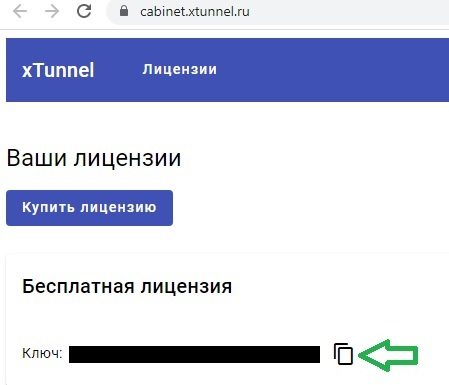

Нажмите на значок ключа (1) на левой панели меню коллаба, вставьте скопированный секретный ключ API в ячейку (4), впишите название ключа XTUNNEL_API_KEY в ячейку (3) и разрешите доступ к этому ключу (2)

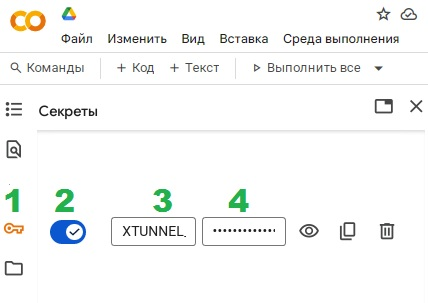

In [ ]:
import os
from google.colab import userdata
os.environ["XTUNNEL_API_KEY"]=userdata.get('XTUNNEL_API_KEY') #<- пароли в коде не храним

In [ ]:
!wget -O xt.zip https://github.com/xtunnel-dev/xtunnel-binaries/raw/refs/heads/main/1.0.20/xtunnel.linux-x64.1.0.20.zip
!unzip xt.zip
!./xtunnel -k $XTUNNEL_API_KEY

--2026-03-29 18:17:25--  https://github.com/xtunnel-dev/xtunnel-binaries/raw/refs/heads/main/1.0.20/xtunnel.linux-x64.1.0.20.zip
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-03-29 18:17:25 ERROR 404: Not Found.

Archive:  xt.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of xt.zip or
        xt.zip.zip, and cannot find xt.zip.ZIP, period.
/bin/bash: line 1: ./xtunnel: No such file or directory


In [ ]:
!pip install fastapi uvicorn scalar_doc nest_asyncio

In [ ]:
%%writefile app.py
from fastapi import FastAPI, HTTPException, Request, responses
from pydantic import BaseModel
from typing import Optional
import xml.etree.ElementTree as ET

# Pydantic-модели

class ItemCreate(BaseModel):
    name: str
    price: int
    rating: int
    category: str
    year: int

class Item(ItemCreate):
    id: int

# Начальные данные (антифризы из DataFrame)

items_db: dict[int, dict] = {
    0: {"id": 0, "name": "Антифриз EURO G11 (-45°C) зелёный, концентрат 5кг",
        "price": 1025, "rating": 11, "category": "Антифриз", "year": 2026},
    1: {"id": 1, "name": "Антифриз зелёный концентрат полный MULTIFREEZE 5кг",
        "price": 250, "rating": 38, "category": "Антифриз", "year": 2025},
    2: {"id": 2, "name": "Антифриз G11 зелёный",
        "price": 120, "rating": 61, "category": "Антифриз", "year": 2025},
    3: {"id": 3, "name": "Антифриз Antifreeze OEM China OAT red -40 5кг",
        "price": 390, "rating": 65, "category": "Антифриз", "year": 2025},
    4: {"id": 4, "name": "Антифриз G11 зелёный",
        "price": 135, "rating": 93, "category": "Антифриз", "year": 2026},
}
next_id = 5

# Утилита: dict → XML

def dict_to_xml(tag: str, d: dict) -> str:
    """Конвертирует словарь в XML-строку."""
    elem = ET.Element(tag)
    for key, val in d.items():
        child = ET.SubElement(elem, str(key))
        child.text = str(val)
    return ET.tostring(elem, encoding="unicode", xml_declaration=False)

def list_to_xml(root_tag: str, item_tag: str, items: list[dict]) -> str:
    """Конвертирует список словарей в XML-строку."""
    root = ET.Element(root_tag)
    for item in items:
        elem = ET.SubElement(root, item_tag)
        for key, val in item.items():
            child = ET.SubElement(elem, str(key))
            child.text = str(val)
    return '<?xml version="1.0" encoding="UTF-8"?>' + ET.tostring(root, encoding="unicode")

# Утилита: выбор формата ответа по заголовку Accept

def make_response(request: Request, data, is_list=False):
    """Возвращает JSON или XML в зависимости от заголовка Accept."""
    accept = request.headers.get("Accept", "application/json")

    if "application/xml" in accept:
        if is_list:
            xml_body = list_to_xml("items", "item", data)
        else:
            xml_body = '<?xml version="1.0" encoding="UTF-8"?>' + dict_to_xml("item", data)
        return responses.Response(content=xml_body, media_type="application/xml")
    else:
        return data  # FastAPI автоматически сериализует в JSON


# FastAPI приложение

DESCRIPTION = """
# Антифриз-каталог API

CRUD-операции для управления каталогом антифризов.
Поддерживает форматы **JSON** и **XML** (через заголовок `Accept`).
"""

app = FastAPI(
    title="Антифриз API",
    description=DESCRIPTION,
    version="1.0.0",
)


# CRUD эндпоинты

@app.get("/items")
def get_items(request: Request):
    """Получить список всех товаров. Accept: application/json или application/xml"""
    items = list(items_db.values())
    return make_response(request, items, is_list=True)


@app.get("/items/{item_id}")
def get_item(item_id: int, request: Request):
    """Получить товар по ID. Accept: application/json или application/xml"""
    if item_id not in items_db:
        raise HTTPException(status_code=404, detail="Item not found")
    return make_response(request, items_db[item_id])


@app.post("/items", status_code=201)
def create_item(item: ItemCreate, request: Request):
    """Добавить новый товар."""
    global next_id
    new_item = {"id": next_id, **item.model_dump()}
    items_db[next_id] = new_item
    next_id += 1
    return make_response(request, new_item)


@app.put("/items/{item_id}")
def update_item(item_id: int, item: ItemCreate, request: Request):
    """Обновить существующий товар по ID."""
    if item_id not in items_db:
        raise HTTPException(status_code=404, detail="Item not found")
    updated = {"id": item_id, **item.model_dump()}
    items_db[item_id] = updated
    return make_response(request, updated)


@app.delete("/items/{item_id}")
def delete_item(item_id: int):
    """Удалить товар по ID."""
    if item_id not in items_db:
        raise HTTPException(status_code=404, detail="Item not found")
    deleted = items_db.pop(item_id)
    return {"detail": "Item deleted", "item": deleted}

Writing app.py


In [ ]:
!echo "скопируй пароль для подключения " && wget -q -O - https://loca.lt/mytunnelpassword
!echo " на странице (введи промпт и нажми Ctrl+Enter)"
!npx localtunnel --port 8000 # не самое лучшее решение для использования на проде

скопируй пароль для подключения 
34.106.200.60 на странице (введи промпт и нажми Ctrl+Enter)
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹your url is: https://polite-cloths-buy.loca.lt


%%html
Сразу тестируйте свой код

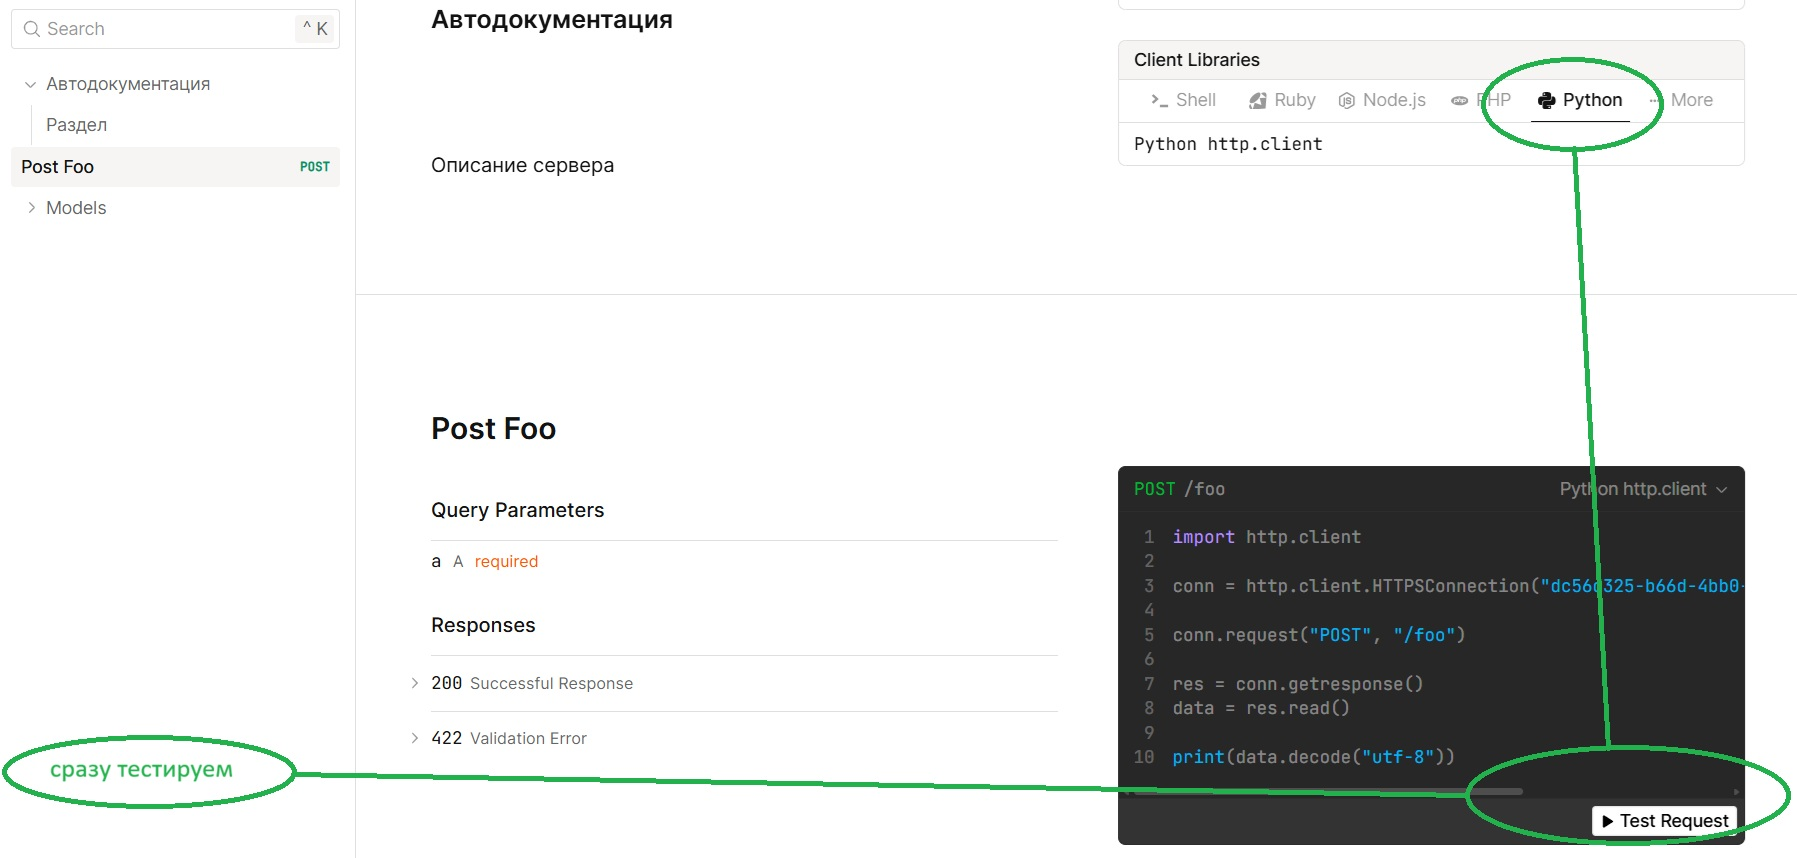

## Проверка результатов — Вывод

В ходе выполнения данной работы были реализованы два подхода к проектированию API: **Code-first** и **API-first**.

При подходе **Code-first** (задания 1–2) мы начали с написания кода сервера — сначала на базе встроенного `http.server`, затем на FastAPI — и уже по готовому коду автоматически генерировалась OpenAPI-спецификация. Это быстрый способ прототипирования: пишем обработчики, запускаем, тестируем. Однако структура API определяется реализацией, а не наоборот, что может привести к непоследовательности интерфейса.

Подход **API-first** (задание 3) предполагает обратный порядок: сначала описывается контракт API в формате OpenAPI/YAML, а затем по нему пишется реализация. Это позволяет заранее согласовать интерфейс между командами (фронтенд и бэкенд), обеспечить единообразие форматов ответа (JSON, XML) и упростить автоматическую генерацию документации и клиентского кода.

Поддержка двух форматов ответа (JSON и XML) через заголовок `Accept` продемонстрировала гибкость API-сервера и важность content negotiation — механизма, позволяющего клиенту запросить данные в удобном ему формате. FastAPI с Pydantic-моделями существенно упрощает валидацию входных данных и автоматическую генерацию документации по сравнению с «голым» `http.server`.

Таким образом, **Code-first** лучше подходит для быстрого прототипирования и внутренних сервисов, тогда как **API-first** — для продуктовых API с множеством потребителей, где стабильность контракта важнее скорости разработки.

## Примечание

Сохраните код работоспособного сервера из [ячейки](#scrollTo=EQRTmZPa2hi1).

Этот сервис пригодится для создания контейнеризированного приложения в ДЗ 4.

In [ ]:
%%sh
git clone https://github.com/iagobalmeida/scalar_doc.git
cd scalar_doc
pip install .

Processing /content/scalar_doc
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for scalar_doc: filename=scalar_doc-0.1.8-py3-none-any.whl size=9857 sha256=94039376dfbbb52a225e0dc9b2e3cc20492132033da30f3ffa2d2ae65a920720
  Stored in directory: /tmp/pip-ephem-wheel-cache-y9n680dc/wheels/9e/24/41/5afc7c1fb9a3846058ec5900595433c40bda34d9fcbef4d11e
Successfully built scalar_doc
  Attempting uninstall: scalar_doc
    Found existing installation: scalar_doc 0.1.8
    Uninstalling scalar_doc-0.1.8:
      Successfully uninstalled scalar_doc-0.1.8


Cloning into 'scalar_doc'...
